In [2]:
import pandas as pd
df = pd.read_csv("D:\\ads work\\2 lac checkig.csv")
df.head()

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke
0,1,65,0,0,207.31,29.9,0,1
1,1,45,0,0,87.90,25.4,1,0
2,0,74,1,1,152.59,31.0,2,1
3,1,49,0,0,116.61,26.7,0,0
4,0,56,0,0,97.04,28.5,2,0


In [3]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [4]:
df.describe()

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.476485,54.706175,0.384810,0.248550,132.708188,28.534969,1.350705,0.500000
std,0.499448,17.730613,0.486552,0.432173,50.450863,5.980832,1.062547,0.500001
min,0.000000,18.000000,0.000000,0.000000,60.000000,15.000000,0.000000,0.000000
25%,0.000000,41.000000,0.000000,0.000000,92.820000,24.300000,0.000000,0.000000
50%,0.000000,57.000000,0.000000,0.000000,118.010000,28.200000,1.000000,0.500000
75%,1.000000,68.000000,1.000000,0.000000,169.920000,32.500000,2.000000,1.000000
max,1.000000,95.000000,1.000000,1.000000,280.000000,55.000000,3.000000,1.000000


In [5]:
y = df.stroke
x = df.drop(['stroke'], axis=1)

In [6]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size = 0.2)

In [7]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Initialize the XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=1000,         # High iterations, similar to your max_iter=6000
    learning_rate=0.05,        # Slow learning for better precision
    max_depth=6,               # Depth of trees (standard for XGBoost)
    reg_lambda=0.5,            # L2 Regularization (Inverse of your C=2.0)
    gamma=0.1,                 # Minimum loss reduction to make a split
    subsample=0.8,             # Use 80% of data to prevent overfitting
    colsample_bytree=0.8,      # Use 80% of features per tree
    scale_pos_weight=1,        # 1 because our new dataset is already 50/50 balanced
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'      # Standard for binary classification
)

# Train the model on the 200k balanced dataset
model.fit(xtrain, ytrain)

# Predict and Evaluate
ypred = model.predict(xtest)
print(classification_report(ytest, ypred))

# 97 or 92

C:\Users\RAHUL\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:35:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.97      0.97      0.97     20073
           1       0.97      0.97      0.97     19927

    accuracy                           0.97     40000
   macro avg       0.97      0.97      0.97     40000
weighted avg       0.97      0.97      0.97     40000



In [8]:
# from sklearn.metrics import classification_report
# from sklearn.linear_model import LogisticRegression
# model = LogisticRegression(
#     class_weight='balanced', # Crucial: gives more weight to the stroke class
#     solver='liblinear',      # Good for smaller datasets or binary classification
#     penalty='l2',            # Regularization to prevent overfitting
#     C=2.0,                   # Inverse of regularization strength; smaller = stronger regularization
#     max_iter=6000            # Gives the model more time to find the best solution
# )
# model.fit(xtrain, ytrain)

# # 96 or 93

In [9]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # Initialize the model with optimized parameters for 200k rows
# model = RandomForestClassifier(
#     n_estimators=500,          # 500 trees is the sweet spot for this data size
#     max_depth=15,              # Limited depth prevents the model from "memorizing" noise
#     min_samples_split=10,      # Requires 10 samples to split a node (prevents tiny branches)
#     min_samples_leaf=4,        # Each leaf must have at least 4 people (smooths predictions)
#     max_features='sqrt',       # Square root of total features (standard best practice)
#     bootstrap=True,            # Uses random subsets of data for each tree
#     n_jobs=-1,                 # USES ALL CPU CORES (important for 200k rows!)
#     random_state=42
# )

# # Train on your new balanced dataset
# model.fit(xtrain, ytrain)

# # Predict and Evaluate
# ypred = model.predict(xtest)
# print(classification_report(ytest, ypred))

# # 97 or 92

In [10]:
y_pred = model.predict(xtest)
y_pred

array([0, 1, 0, ..., 1, 0, 1], shape=(40000,))

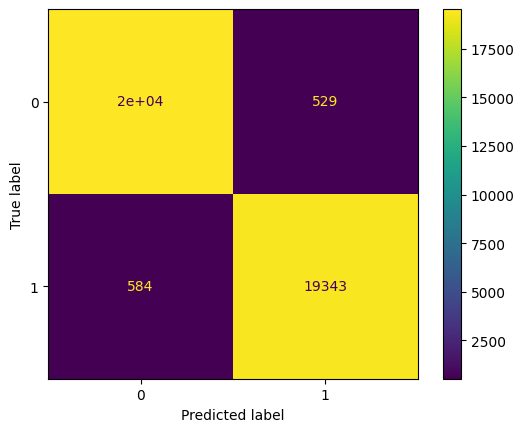

In [11]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm = confusion_matrix(ytest , y_pred)
dp = ConfusionMatrixDisplay(cm)
dp.plot()

In [12]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     20073
           1       0.97      0.97      0.97     19927

    accuracy                           0.97     40000
   macro avg       0.97      0.97      0.97     40000
weighted avg       0.97      0.97      0.97     40000



###  CHEKING ON NEW DATASET

In [13]:
df1 = pd.read_csv("D:\\ads work\\encoded_synthetic_test_stroke_20k.csv")
df1.head()

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke
0,0,77.7,1,0,218.82,36.273151,2,1
1,0,72.0,0,0,99.47,33.957762,3,0
2,0,54.6,0,0,79.47,29.672739,0,0
3,0,41.8,0,1,98.77,25.198492,2,0
4,1,59.6,0,0,168.27,39.584363,2,1


In [14]:
# 1. Create X by dropping the target column 'stroke'
# axis=1 means we are dropping a column, not a row
xx = df1.drop('stroke', axis=1)

# 2. Create y by selecting ONLY the 'stroke' column
yy = df1['stroke']

# View the first few rows of your features
print(xx.head())

   gender   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0       0  77.7             1              0             218.82  36.273151   
1       0  72.0             0              0              99.47  33.957762   
2       0  54.6             0              0              79.47  29.672739   
3       0  41.8             0              1              98.77  25.198492   
4       1  59.6             0              0             168.27  39.584363   

   smoking_status  
0               2  
1               3  
2               0  
3               2  
4               2  


In [15]:
x_train0, x_test0, y_train0, y_test0 = train_test_split(xx,yy, test_size=0.99, random_state=45)

In [16]:
y_pred0 = model.predict(x_test0)
y_pred0

array([1, 0, 1, ..., 0, 1, 0], shape=(19800,))

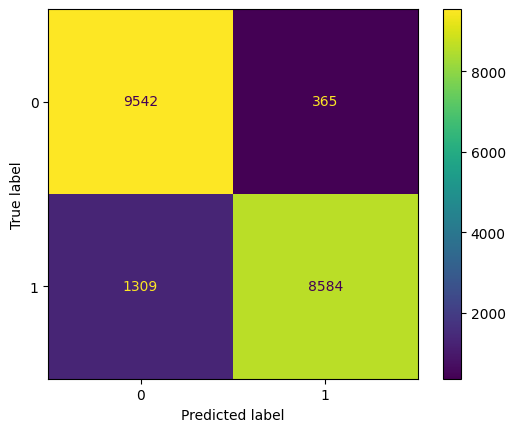

In [17]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm1 = confusion_matrix(y_test0 , y_pred0)
dp1 = ConfusionMatrixDisplay(cm1)
dp1.plot()

In [18]:
print(classification_report(y_test0, y_pred0))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      9907
           1       0.96      0.87      0.91      9893

    accuracy                           0.92     19800
   macro avg       0.92      0.92      0.92     19800
weighted avg       0.92      0.92      0.92     19800



In [19]:
df1.head()

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke
0,0,77.7,1,0,218.82,36.273151,2,1
1,0,72.0,0,0,99.47,33.957762,3,0
2,0,54.6,0,0,79.47,29.672739,0,0
3,0,41.8,0,1,98.77,25.198492,2,0
4,1,59.6,0,0,168.27,39.584363,2,1


In [20]:
import numpy as np
input_data = np.array([[0,72.7,0,0,99,33,3]])
prediction = model.predict(input_data)
print(prediction)

[0]


In [21]:
import pickle

# Save the trained XGBoost model to a file
with open('stroke_model.pkl', 'wb') as file:
    pickle.dump(model, file)
    
print("Model saved successfully as stroke_model.pkl!")

Model saved successfully as stroke_model.pkl!
